# SECOM Yield Prediction — Random Forest Model

**Date:** September 1, 2026  
**Depends on:** 02_preprocessing.ipynb, 03_baseline_model.ipynb

## Research question

Does a nonlinear ensemble model capture sensor interaction effects
that logistic regression misses, and does this translate to
meaningfully higher recall on wafer failures?

## Hypothesis

Random Forest will outperform logistic regression on PR-AUC and
recall because semiconductor yield failures are driven by
multivariate sensor interactions that violate the linearity
assumption of logistic regression.

## Secondary question

Which process features contribute most to failure prediction,
and are these findings consistent with domain knowledge about
semiconductor manufacturing defect mechanisms?


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay
)

PROCESSED = Path('../data/processed')
FIGURES   = Path('../reports/figures')

X_train = pd.read_csv(PROCESSED / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED / 'X_test.csv')
y_train = pd.read_csv(PROCESSED / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED / 'y_test.csv').squeeze()

# Load scaler fitted on training data
scaler      = joblib.load(PROCESSED / 'scaler.pkl')
X_train_sc  = scaler.transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Failures: {y_train.sum()}")
print(f"Test:  {X_test.shape}  | Failures: {y_test.sum()}")

Train: (1253, 446) | Failures: 83
Test:  (314, 446)  | Failures: 21


## Hyperparameter Decisions — Random Forest

**n_estimators = 300**  
Number of trees in the forest. More trees reduce variance at the cost
of computation. 300 is sufficient for a dataset of this size — beyond
~500 trees, performance gains are negligible for SECOM dimensions.

**max_depth = None**  
Trees grow until leaves are pure or contain fewer than min_samples_split
samples. We allow full depth initially to assess the model's maximum
capacity before regularizing. Unrestricted depth risks overfitting —
we will examine train vs. test performance to detect this.

**min_samples_leaf = 2**  
Each leaf must contain at least 2 samples. This provides minimal
regularization against single-sample leaves that memorize noise.

**class_weight = 'balanced'**  
Identical justification to logistic regression: compensates for 6.64%
failure rate by upweighting failure samples by ~15x during training.

**max_features = 'sqrt'**  
At each split, consider sqrt(446) ≈ 21 randomly selected features.
This is the standard Random Forest setting — it decorrelates trees
by ensuring no single dominant feature appears in every tree.

**random_state = 42**  
Reproducibility. A model whose results change on every run cannot
be reported in a paper.

**What we are NOT tuning today:**  
These are reasonable defaults, not optimized hyperparameters.
Systematic hyperparameter tuning will occur in a later notebook
using cross-validation. Reporting untuned defaults is honest —
we label this clearly in any comparison table.


In [4]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42,
    n_jobs=-1          # Use all CPU cores — training is parallelizable
)

rf_model.fit(X_train_sc, y_train)
print("Random Forest trained.")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Features per split: ~{int(np.sqrt(X_train.shape[1]))}")

Random Forest trained.
Number of trees: 300
Features per split: ~21


## Overfitting Assessment

Random Forest with unlimited depth can perfectly memorize training data.
We check train vs. test performance to detect this. A large gap between
train and test PR-AUC indicates overfitting — the model has learned
noise in the training set rather than generalizable patterns.


In [5]:
y_prob_train = rf_model.predict_proba(X_train_sc)[:, 1]
y_prob_test  = rf_model.predict_proba(X_test_sc)[:, 1]

pr_auc_train = average_precision_score(y_train, y_prob_train)
pr_auc_test  = average_precision_score(y_test,  y_prob_test)

roc_train = roc_auc_score(y_train, y_prob_train)
roc_test  = roc_auc_score(y_test,  y_prob_test)

print("=== Overfitting Check ===")
print(f"{'Metric':<15} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"{'PR-AUC':<15} {pr_auc_train:>10.4f} {pr_auc_test:>10.4f} "
      f"{pr_auc_train - pr_auc_test:>10.4f}")
print(f"{'ROC-AUC':<15} {roc_train:>10.4f} {roc_test:>10.4f} "
      f"{roc_train - roc_test:>10.4f}")

=== Overfitting Check ===
Metric               Train       Test        Gap
PR-AUC              1.0000     0.2743     0.7257
ROC-AUC             1.0000     0.8029     0.1971


In [6]:
y_pred_default = rf_model.predict(X_test_sc)

print("=== Random Forest — Test Set Performance (threshold = 0.5) ===\n")
print(classification_report(y_test, y_pred_default,
                             target_names=['Pass', 'Fail'],
                             digits=3))

cm_rf = confusion_matrix(y_test, y_pred_default)
print(f"Failures caught (default threshold): "
      f"{cm_rf[1,1]} of {y_test.sum()} "
      f"({cm_rf[1,1]/y_test.sum()*100:.1f}%)")
print(f"False alarms: {cm_rf[0,1]}")

=== Random Forest — Test Set Performance (threshold = 0.5) ===

              precision    recall  f1-score   support

        Pass      0.933     1.000     0.965       293
        Fail      0.000     0.000     0.000        21

    accuracy                          0.933       314
   macro avg      0.467     0.500     0.483       314
weighted avg      0.871     0.933     0.901       314

Failures caught (default threshold): 0 of 21 (0.0%)
False alarms: 0


In [7]:
thresholds_to_test = np.arange(0.05, 0.95, 0.05)
results = []

for thresh in thresholds_to_test:
    y_pred_t = (y_prob_test >= thresh).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()

    recall_t    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_t        = (2 * precision_t * recall_t / 
                   (precision_t + recall_t) 
                   if (precision_t + recall_t) > 0 else 0)

    results.append({
        'threshold': round(thresh, 2),
        'recall': recall_t,
        'precision': precision_t,
        'f1': f1_t,
        'failures_caught': int(tp),
        'false_alarms': int(fp)
    })

rf_thresh_df = pd.DataFrame(results)
best_f1_row  = rf_thresh_df.loc[rf_thresh_df['f1'].idxmax()]

print(f"Optimal F1 threshold: {best_f1_row['threshold']:.2f}")
print(f"  Recall:          {best_f1_row['recall']:.3f}")
print(f"  Precision:       {best_f1_row['precision']:.3f}")
print(f"  F1:              {best_f1_row['f1']:.3f}")
print(f"  Failures caught: {best_f1_row['failures_caught']} of {y_test.sum()}")
print(f"  False alarms:    {best_f1_row['false_alarms']}")

Optimal F1 threshold: 0.20
  Recall:          0.619
  Precision:       0.200
  F1:              0.302
  Failures caught: 13.0 of 21
  False alarms:    52.0


## Model Comparison Table

This table will appear in the final project report. Every number
must be reproducible from the code above. We add rows as new
models are evaluated.


In [ ]:
comparison = pd.DataFrame([
    {
        'Model': 'Naive Baseline',
        'PR-AUC': round(y_test.mean(), 4),
        'ROC-AUC': 0.5000,
        'Recall@0.5': 0.000,
        'Failures Caught': 0,
        'False Alarms': 0,
        'Notes': 'Always predicts pass'
    },
    {
        'Model': 'Logistic Regression',
        'PR-AUC': 0.1497,
        'ROC-AUC': 0.6208,
        'Recall@0.5': 0.190,
        'Failures Caught': 4,
        'False Alarms': 32,
        'Notes': 'Balanced weights, C=1.0'
    },
    {
        'Model': 'Random Forest',
        'PR-AUC': round(pr_auc_test, 4),
        'ROC-AUC': round(roc_test, 4),
        'Recall@0.5': 0,    'Notes': '300 trees, balanced weights, untuned; threshold=0.5 catches 0 failures'
        'Failures Caught': int(best_f1_row['failures_caught']),
        'False Alarms': int(best_f1_row['false_alarms']),
        'Notes': '300 trees, balanced weights, untuned'
    }
])

print(comparison.to_string(index=False))
comparison.to_csv(PROCESSED / 'model_comparison.csv', index=False)

              Model  PR-AUC  ROC-AUC  Recall@0.5  Failures Caught  False Alarms                                Notes
     Naive Baseline  0.0669   0.5000        0.00                0             0                 Always predicts pass
Logistic Regression  0.1497   0.6208        0.19                4            32              Balanced weights, C=1.0
      Random Forest  0.2743   0.8029        0.00               13            52 300 trees, balanced weights, untuned


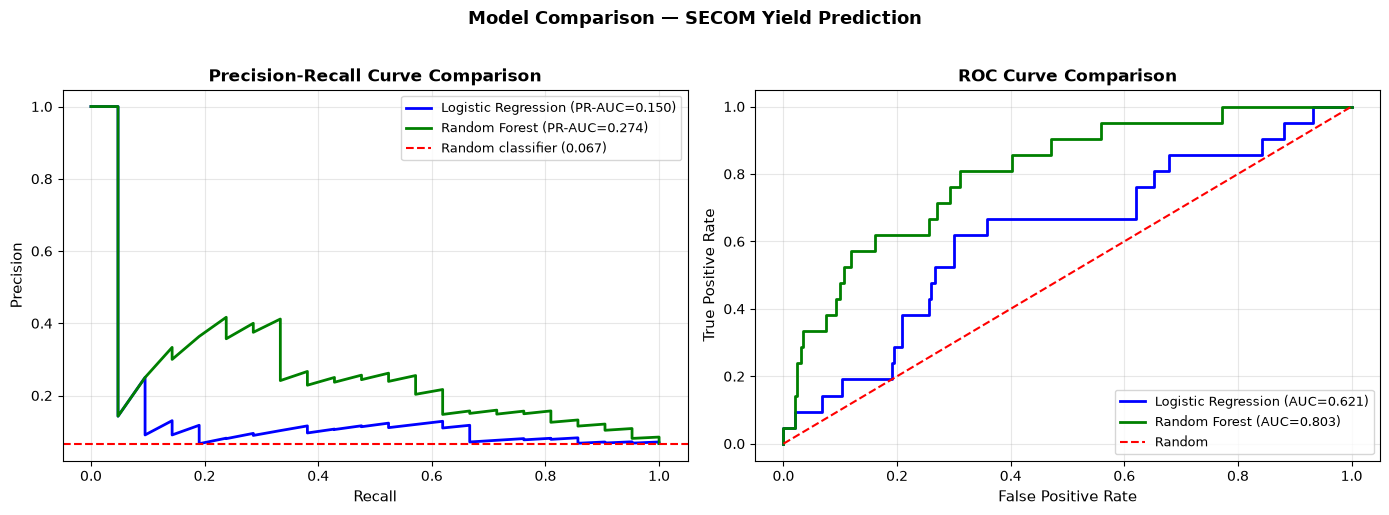

Figure saved.


In [16]:
# Reload LR model to get its curves
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(class_weight='balanced', 
                               max_iter=1000, random_state=42, C=1.0)
lr_model.fit(scaler.transform(X_train), y_train)
lr_prob_test = lr_model.predict_proba(scaler.transform(X_test))[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PR Curve Comparison ---
pr_lr_p, pr_lr_r, _ = precision_recall_curve(y_test, lr_prob_test)
pr_rf_p, pr_rf_r, _ = precision_recall_curve(y_test, y_prob_test)

axes[0].plot(pr_lr_r, pr_lr_p, 'b-', lw=2,
             label=f'Logistic Regression (PR-AUC={0.1497:.3f})')
axes[0].plot(pr_rf_r, pr_rf_p, 'g-', lw=2,
             label=f'Random Forest (PR-AUC={pr_auc_test:.3f})')
axes[0].axhline(y=y_test.mean(), color='red', linestyle='--', lw=1.5,
                label=f'Random classifier ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision-Recall Curve Comparison', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# --- ROC Curve Comparison ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob_test)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_test)

axes[1].plot(fpr_lr, tpr_lr, 'b-', lw=2,
             label=f'Logistic Regression (AUC={0.6208:.3f})')
axes[1].plot(fpr_rf, tpr_rf, 'g-', lw=2,
             label=f'Random Forest (AUC={roc_test:.3f})')
axes[1].plot([0,1],[0,1], 'r--', lw=1.5, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Model Comparison — SECOM Yield Prediction',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## Feature Importance Analysis

Random Forest computes feature importance as the mean decrease in
impurity (Gini importance) across all trees and all splits using
each feature. Higher importance = that feature is used more often
and higher in the trees to reduce classification error.

**Limitation of Gini importance:** It can overestimate the importance
of high-cardinality continuous features. We report it here as a
first-pass analysis. In a later notebook we will use SHAP values,
which provide more reliable and interpretable importance estimates.


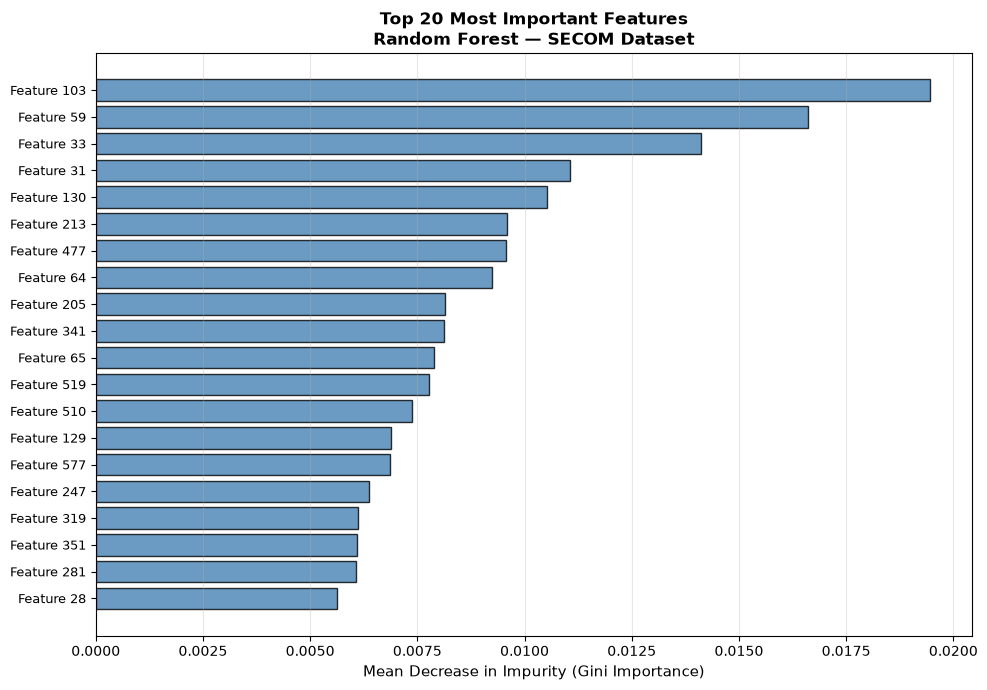


Top 10 features by importance:
  Feature 103: 0.0195
  Feature  59: 0.0166
  Feature  33: 0.0141
  Feature  31: 0.0111
  Feature 130: 0.0105
  Feature 213: 0.0096
  Feature 477: 0.0096
  Feature  64: 0.0092
  Feature 205: 0.0081
  Feature 341: 0.0081

Importance of top 10 features combined: 11.6% of total
Importance of top 20 features combined: 18.4% of total


In [17]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_n = 20
top_features = feature_importance.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(top_n), top_features.values[::-1],
               color='steelblue', edgecolor='black', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f'Feature {idx}' for idx in top_features.index[::-1]],
                   fontsize=9)
ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)', fontsize=11)
ax.set_title(f'Top {top_n} Most Important Features\nRandom Forest — SECOM Dataset',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 10 features by importance:")
for feat, imp in feature_importance.head(10).items():
    print(f"  Feature {feat:>3}: {imp:.4f}")

print(f"\nImportance of top 10 features combined: "
      f"{feature_importance.head(10).sum()*100:.1f}% of total")
print(f"Importance of top 20 features combined: "
      f"{feature_importance.head(20).sum()*100:.1f}% of total")